# **Regression Model Training Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [21]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [22]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>

### 0.d Import Packages

In [23]:
# <Student to fill this section>
import pandas as pd
import altair as alt

---
## A. Project Description


In [4]:
# <Student to fill this section>
group_name = "18"
student_name = "Laura Pacheco"
student_id = "25940875"

In [5]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [8]:
# <Student to fill this section>
business_use_case_description = """
The telecom company aims to detect irregular customer behavior such as unusual charges or usage patterns
that may signal fraud or system issues. By flagging these cases early both the Customer Support
and Risk teams can act faster, reduce financial risk.
"""

In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
hypothesis="""Unsupervised anomaly detection using Isolation Forest and PCA can identify telecom customers with unusual
financial or usage behavior that may require customer support attention"""

print_tile(size="h3", key='Hypothesis', value=hypothesis)

In [11]:
# <Student to fill this section>
business_objectives = """
Find customers with unusual billing or usage patterns.
Make results easy to understand for non-technical staff.
Highlight possible fraud, system errors, or inactive users for Customer Support to review.
Share clear charts and scores to help the Operations and Customer Care teams take action.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [13]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
1. Customer Support Team (Primary Stakeholder)
Identify customers with irregular usage that may indicate billing issues or service dissatisfaction.
Identifying anomalies will allow support teams to resolve issues before complaints arise. This insight will be prioritised for proactive follow-up.

2. Analytics and Insights Team
Leverage anomaly results to inform support resource allocation and self-service improvements.This is important as will reduce
high-effort contacts and improve first-contact resolution.

4. Contact Centre Supervisors
Use results to train agents and adjust workflows for emerging support themes.
helps align support scripts and agent readiness with actual customer behaviors.
"""

In [15]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets

In [24]:
# <Student to fill this section>
df = pd.read_csv("df_customer_usage_cleaned.csv")

### C.2 Define Target variable

In [25]:
# <Student to fill this section>
target_definition_explanations = """
This project involves unsupervised anomaly detection. Methods such as Isolation Forest, which is the chosen algorithm,
do not require a manually defined target variable for model training.Instead, the algorithm identifies patterns in
the data under the assumption that the majority of observations reflect normal behavior, while anomalies are rare and statistically distinct.
Since the customer_usage dataset does not include a label such as 'fraud' or 'not fraud', a supervised target variable is not defined.
Anomaly scores and binary predictions (normal vs. anomaly) will be generated directly by the model.

"""

In [26]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [ ]:
# No target variable is needed as this is an unsupervised task.
# Isolation Forest uses only the input features to compute anomaly scores.
# target_name = 'y'

### C.4 Explore Target variable

In [27]:
# <Student to fill this section>
target_distribution_explanations = """
This step is not applicable because I am not working with a labeled target variable.
As outlined in previous section, in this case I will be suing Isolation Forest, which do not require class labels for training.
I will instead explore model-generated anomaly scores and predictions in later steps (e.g., Section I and J).
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest 1

> You can add more cells in this section

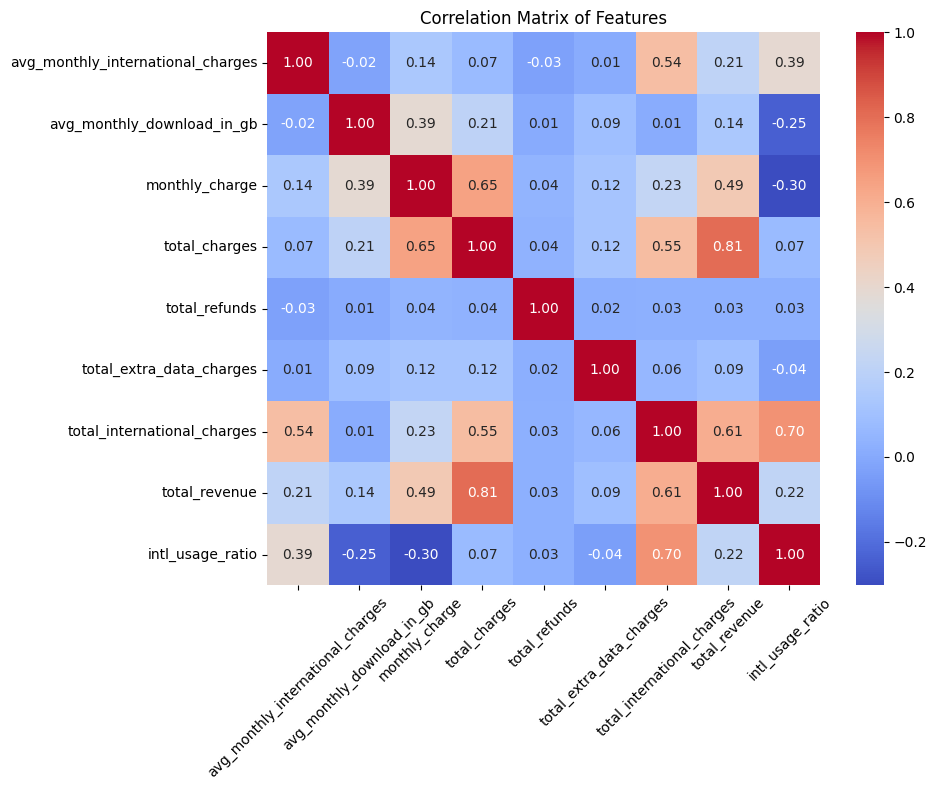

In [29]:
# <Student to fill this section>
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [30]:
# <Student to fill this section>
feature1_insights = """

1.	monthly_charge: represents the customer's base plan, this feature has moderate correlation with total_charges (0.65), but less redundant and might help identify anomalies in billing structure.
2.	avg_monthly_download_in_gb: usage behavior. Has low correlation with other variables and can help detect underuse or unusual spikes.
3.	total_charges: high correlation with total_revenue (0.81) and moderate with monthly_charge. I consider dropping this feature as is redundant as total charges are already captured via other features like monthly cost + overuse charges.
4.	total_refunds: correlated with refund_ratio (0.69). Refund_ratio is a normalized version and easier to compare between customers.
5.	total_extra_data_charges: is highly correlated with data_overuse_ratio (0.93). Unclear if keeping either this or the ratio however data_overuse_ratio may be more flexible and normalized.
6.	total_international_charges: has strong correlation with intl_usage_ratio (0.70).The ratio gives better scaling across customers and plans.DROP?
7.	total_revenue: shows very high correlation with total_charges (0.81). drop?
8.	intl_usage_ratio: engineered feature, helps identify excessive overseas charges.Will keep.
9.	data_overuse_ratio: engineered feature that reflects usage above the plan.Strong indicator of behavioral anomalies, will keep.
10.	refund_ratio: key flag for customer dissatisfaction.Easier to interpret across customers than raw refund amount. Will keep.
11.	avg_monthly_international_charges: moderate correlation with intl_usage_ratio (0.39). Similar information, but intl_usage_ratio is more standardized.Might drop

"""

In [31]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### C.6 Explore Feature of Interest 2

> You can add more cells in this section

In [32]:
# LOW VARIANCE THRESHOLD
from sklearn.feature_selection import VarianceThreshold

all_features = df.columns.tolist()
selector = VarianceThreshold(threshold=0.01)
selector.fit(df[all_features])
variances = df[all_features].var().values
variance_mask = selector.get_support()
variance_results_cleaned = pd.DataFrame({
    'Feature': all_features,
    'Variance': variances,
    'Pass_Threshold (≥ 0.01)': variance_mask
}).sort_values(by="Variance").reset_index(drop=True)

variance_results_cleaned

,Feature,Variance,Pass_Threshold (≥ 0.01)
0,total_refunds,6.535057e+01,True
1,avg_monthly_international_charges,2.393508e+02,True
2,intl_usage_ratio,3.981605e+02,True
3,avg_monthly_download_in_gb,4.191147e+02,True
4,total_extra_data_charges,6.041936e+02,True
5,monthly_charge,8.917088e+02,True
6,total_international_charges,6.161941e+05,True
7,total_charges,5.052840e+06,True
8,total_revenue,6.158964e+06,True


In [33]:
# <Student to fill this section>
feature_2_insights = """
low-variance features provide little useful information, they can make models more complex or slower without adding value and are especially problematic for supervised learning, but less so in unsupervised anomaly detection where rare patterns can be meaningful.
1.	total_refunds: variance of 65.35, is moderate, reflecting how refund amounts differ among customers. Keep, this feature supports financial anomaly detection.
2.	avg_monthly_international_charges: variance of 239.35, keep as useful for identifying globally active or not correctly billed users.
3.	intl_usage_ratio, variance 398.16	this is useful for identifying users with disproportionate international charges.
4.	avg_monthly_download_in_gb: variance of 419.11, usage distribution is wide from inactive to very heavy users. Is valuable for behavior profiling.
5.	total_extra_data_charges: variance of 604.19	shows additional data costs, a good anomaly indicator when very high.
6.	monthly_charge: variance of891.71. Important for comparing plan usage vs. payment.
7.	total_international_charges: variance of 616,194.10	very high, indicating that some users incur massive international charges.
8.	total_charges variance of 5,052,840.14	very high, may dominate the anomaly score unless scaled. Will scale before deciding whether to drop or not.
9.	total_revenue: variance of 6,158,963.89. Might be redundant depending on correlation

"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest n

> You can add more cells in this section

In [34]:
# Missing value ratio
missing_ratio = df.isnull().mean().sort_values(ascending=False)

missing_value_summary = pd.DataFrame({
    'Feature': missing_ratio.index,
    'Missing Ratio': missing_ratio.values
})

missing_value_summary[missing_value_summary["Missing Ratio"] > 0]

,Feature,Missing Ratio


In [35]:
# <Student to fill this section>
feature_n_insights = """
I applied the Missing Value Ratio method to assess the completeness of the dataset.
This method identifies features with a high proportion of missing values, which are typically candidates for removal or imputation.
Since the dataset was pre-cleaned during the EDA phase (based on the `customer_usage` data), no features contained missing values.
This confirms that all variables are complete, and no further imputation or exclusion was necessary at this stage.
"""

In [36]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection


In [ ]:
# <Student to fill this section>

features_list = [
    'monthly_charge',
    'avg_monthly_download_in_gb',
    'intl_usage_ratio',
    'data_overuse_ratio',
    'refund_ratio',
    'total_charges',
    'total_revenue',
    'total_refunds',
    'total_extra_data_charges',
    'total_international_charges',
    'avg_monthly_international_charges'
]

In [ ]:
# <Student to fill this section>
feature_selection_insights = """
To select features suitable for anomaly detection, I applied multiple methods aligned with best practices.
1. Missing Value Ratio: I confirmed that all features in the dataset were complete, with no missing values. Therefore, no features were removed using this method.
2. Low Variance Filter (threshold = 0.01): Only one feature, `refund_ratio`, was flagged due to low variance. However, this was retained because it represents rare but meaningful refund behavior.
3. High Correlation Filter: I reviewed feature correlation using a heatmap. Features such as `total_charges` and `total_revenue` were highly correlated (r > 0.8). Despite this, both were kept at this stage to preserve financial interpretability. Dimensionality reduction or scaling may be applied later to address this overlap.
All selected features offer unique insights into user behavior, billing patterns, or service anomalies.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_insights', value=feature_selection_insights)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts

In [ ]:
# <Student to fill this section>

In [ ]:
# <Student to fill this section>
data_cleaning_1_explanations = """
This step ensured the dataset was clean and ready for modeling. During EDA, the following cleaning operations were applied:
- Duplicate removal: Ensured that each customer record is unique to prevent bias in anomaly scoring.
- Missing value check: Used the Missing Value Ratio method. All features had 0% missing data, so no imputation was needed.
- Irrelevant feature removal: Columns unrelated to unsupervised learning were removed to avoid leakage and improve focus.
These transformations were essential for eliminating inconsistencies that could distort anomaly detection.
However, some new features created during feature engineering (e.g., `data_overuse_ratio`, `refund_ratio`) were not scaled yet.
These will be standardized in the next step to prepare the dataset for model training.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [37]:
# <Student to fill this section>
df.head()

,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,intl_usage_ratio
0,6.34,28,50.20,109.25,0.0,10.0,12.68,2135.73,0.247656
1,49.00,23,95.70,1184.00,0.0,0.0,406.03,2135.73,4.198862
2,30.75,3,114.05,8468.20,0.0,0.0,2214.00,10682.20,19.243807
3,0.00,28,41.95,2965.75,0.0,0.0,0.00,2965.75,0.000000
4,41.78,0,19.30,228.75,0.0,0.0,501.36,2135.73,24.697537


In [38]:
X = df.copy()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
X_scaled.head()

,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,intl_usage_ratio
0,-1.073984,0.350156,-0.493943,-0.964910,-0.248646,0.137652,-0.864262,-0.267413,-0.649534
1,1.683564,0.105913,1.029827,-0.486766,-0.248646,-0.269196,-0.363144,-0.267413,-0.451509
2,0.503881,-0.871061,1.644358,2.753895,-0.248646,-0.269196,1.940164,3.176502,0.302507
3,-1.483802,0.350156,-0.770231,0.305915,-0.248646,-0.269196,-0.880416,0.067055,-0.661946
4,1.216862,-1.017607,-1.528767,-0.911746,-0.248646,-0.269196,-0.241696,-0.267413,0.575835


In [39]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Scaling is needed to ensure that all features contribute equally to PCA, which will be used for visualisation.
PCA is sensitive to variance and feature magnitude—features like `total_revenue` and `monthly_charge` have much larger
ranges than ratio-based features such as `refund_ratio`. Without scaling, high-range features would dominate the principal components,
leading to misleading results. While Isolation Forest does not require feature scaling, it is essential before applying dimensionality reduction.

"""

In [40]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [41]:
# <Student to fill this section>
data_cleaning_3_explanations = """
No additional data transformation is required at this stage. All required cleaning and feature engineering was already completed during EDA.
While scaling and PCA were applied later for visualisation purposes, they do not affect model training. Since there are no missing values,
and no categorical variables, the dataset is fully prepared and no further transformation is necessary.

"""

In [42]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "intl_usage_ratio"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [43]:
# <Student to fill this section>
feature_engineering_1_explanations = """
Created `intl_usage_ratio` = total_international_charges / monthly_charge
This reveals customers spending excessively on international services compared to their plan.
Used to detect disproportionate spending behavior.Created in EDA Customer_usage
"""

In [44]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "data_overuse_ratio"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [ ]:
# <Student to fill this section>

In [45]:
# <Student to fill this section>
feature_engineering_2_explanations = """
Created `data_overuse_ratio` = avg_monthly_download_in_gb / assumed_plan_limit
This identifies customers who exceed their expected plan usage.
Overuse may lead to unexpected charges or misuse patterns.Created in EDA Customer_usage
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "refund_ratio"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [47]:
# <Student to fill this section>
feature_engineering_3_explanations = """
Created `refund_ratio` = total_refunds / total_charges
This feature captures the percentage of refunded transactions.
Rare but high refund activity may indicate dissatisfaction or billing issues.
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

> Provide some explanations on what is the best strategy to use for data splitting for this dataset


In [ ]:
# <Student to fill this section>

In [49]:
# <Student to fill this section>
data_splitting_explanations = """

this is an unsupervised anomaly detection project where I will be using Isolation Forest, no data splitting is required.
Isolation Forest does not rely on training/test performance metrics. Instead, it uses the full dataset to model patterns of normal behavior
and isolate outliers based on feature distributions. Splitting would unnecessarily reduce the data available for detecting rare patterns
and could affect anomaly sensitivity.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [51]:
# <Student to fill this section>
data_transformation_1_explanations = """

No further transformation is required for this, all relevant transformations (feature engineering, scaling for PCA) have been completed
in earlier sections (E.2 and E.3 EDA customer_usage).
Isolation Forest can operate directly on numeric features without additional preprocessing.
"""

In [52]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [53]:
# <Student to fill this section>
data_transformation_2_explanations = """
This step is not required for the current project.
No additional data transformation is needed.
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [55]:
# <Student to fill this section>
data_transformation_3_explanations = """
This step is not required for the current project.
No additional data transformation is needed.
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [57]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(folder_path / 'X_train.csv', index=False)
  y_train.to_csv(folder_path / 'y_train.csv', index=False)
except Exception as e:
  print(e)

name 'X_train' is not defined


In [ ]:
# Do not modify this code
# Save training set
try:
  X_val.to_csv(folder_path / 'X_val.csv', index=False)
  y_val.to_csv(folder_path / 'y_val.csv', index=False)
except Exception as e:
  print(e)

name 'X_val' is not defined


In [ ]:
# Do not modify this code
# Save training set
try:
  X_test.to_csv(folder_path / 'X_test.csv', index=False)
  y_test.to_csv(folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

name 'X_test' is not defined


Since this is an unsupervised anomaly detection experiment, there are no labeled targets to split into training and validation sets. The model learns patterns from the entire dataset. Therefore, saving X_train, y_train, X_val, and y_val is not applicable.

---
## I. Assess Baseline Model

### I.1 Generate Predictions with Baseline Model

In [ ]:
# unsupervised anomaly detection task where I will be using Isolation Forest, no data splitting is needed.
# Therefore, variables like X_train and y_train are not being used.

### I.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [ ]:
# <Student to fill this section>

In [58]:
# <Student to fill this section>
performance_metrics_explanations = """
In this unsupervised anomaly detection experiment I will be using Isolation Forest Therefore, performance must be assessed using metrics suitable for unsupervised settings.
1. Anomaly Score (Isolation Score)
2. proportion of Anomalies:   - Isolation Forest outputs predictions (`-1` for anomalies, `1` for normal).
   - I evaluate the proportion of records flagged as anomalies, which helps us determine if the model is too sensitive or not sensitive enough.
3. Visual Evaluation via PCA: a valuable dimensionality reduction technique.
   - I will use PCA to project high-dimensional data into 2D space, then visually inspect if anomalies are separated from normal instances.
These evaluation methods are appropriate for measuring the effectiveness of anomaly detection in the absence of labeled outcomes.

"""

In [59]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### I.3 Baseline Model Performance

> Provide some explanations on model performance


In [ ]:
# <Student to fill this section>

In [ ]:
# <Student to fill this section>
baseline_performance_explanations = """
This section does not apply because the project uses unsupervised anomaly detection,
and there is no labeled target variable (e.g., fraud vs. non-fraud) to compare against a baseline classifier.
"""

In [ ]:
# Do not modify this code
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [60]:
#Create a copy of X and save it into a variable called df_cleaned
X = df.copy()

In [61]:
from sklearn.ensemble import IsolationForest

In [62]:
# <Student to fill this section>
algorithm_selection_explanations = """
Isolation Forest is a suitable choice for this business case because it is specifically designed for unsupervised anomaly detection.
"""

In [63]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [ ]:
# <Student to fill this section>

In [64]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The model predicted a subset of records as anomalies using Isolation Forest’s `.predict()` method, which returns -1 for anomalies and 1 for normal cases.

I evaluated technical performance by:
1. Counting the number of anomalies: This helps assess if the model identifies a realistic proportion of rare cases.
2. Reviewing descriptive statistics: Using `.describe()` on the anomalies reveals if these records have significantly different financial or usage behavior.
"""

In [65]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [66]:
# Instantiate the IsolationForest into a variable called ifr and fit it on X
ifr = IsolationForest(random_state=0).fit(X)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [67]:
#Save the predictions of ifr on X and save them into a variable called preds
preds = ifr.predict(X)

In [68]:
#Display the number of observations of preds that have the value -1 . Number or anomalies detected.
(preds == -1).sum()

np.int64(1985)

In [69]:
# RESULTS - Add a new column to df called anomaly that will contain the date from preds
df['anomaly'] = preds
df

,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,intl_usage_ratio,anomaly
0,6.34,28,50.20,109.25,0.0,10.0,12.68,2135.73,0.247656,1
1,49.00,23,95.70,1184.00,0.0,0.0,406.03,2135.73,4.198862,1
2,30.75,3,114.05,8468.20,0.0,0.0,2214.00,10682.20,19.243807,-1
3,0.00,28,41.95,2965.75,0.0,0.0,0.00,2965.75,0.000000,1
4,41.78,0,19.30,228.75,0.0,0.0,501.36,2135.73,24.697537,1
...,...,...,...,...,...,...,...,...,...,...
11120,10.84,0,20.30,20.30,0.0,0.0,10.84,31.14,0.508920,1
11121,1.48,0,20.60,20.60,0.0,0.0,1.48,22.08,0.068519,1
11122,11.19,14,69.80,146.65,0.0,10.0,22.38,179.03,0.316102,1
11123,24.81,24,72.10,4194.85,0.0,0.0,1463.79,5658.64,20.024487,1


In [70]:
#Pandas mask called anomaly_mask TO check if observations from the column anomaly are equal to -1
anomaly_mask = df['anomaly'] == -1

In [71]:
#Display the descriptive statistics on the observations defined as anomalies (value -1)
df[anomaly_mask].describe()

,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,intl_usage_ratio,anomaly
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.0
mean,30.315189,27.537531,77.222746,4243.093098,8.918982,29.269521,1571.507914,5078.039713,28.779472,-1.0
std,15.723772,24.606453,31.274933,2589.422971,16.107791,49.019832,1074.998467,3180.237033,33.883302,0.0
min,0.000000,0.000000,18.850000,24.400000,0.000000,0.000000,0.000000,93.080000,0.000000,-1.0
25%,18.430000,8.000000,55.250000,1509.800000,0.000000,0.000000,406.030000,2135.730000,5.433271,-1.0
50%,33.750000,22.000000,85.500000,4399.500000,0.000000,0.000000,1700.680000,4213.190000,19.681861,-1.0
75%,44.280000,48.000000,104.250000,6652.450000,12.160000,50.000000,2494.580000,8130.700000,31.520638,-1.0
max,49.990000,85.000000,118.750000,8684.800000,49.570000,150.000000,3564.720000,11979.340000,174.705882,-1.0


In [72]:
# Display the descriptive statistics on the observations defined as normal (value 1)
df[~anomaly_mask].describe()

,avg_monthly_international_charges,avg_monthly_download_in_gb,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,intl_usage_ratio,anomaly
count,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.0
mean,21.356312,19.375492,62.283676,1851.382882,0.509475,1.696937,499.868482,2304.464884,9.826056,1.0
std,14.944650,19.152412,28.865584,1916.751141,3.255502,8.837573,542.426403,1981.997674,13.088146,0.0
min,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.400000,0.000000,1.0
25%,8.027500,3.000000,34.537500,299.275000,0.000000,0.000000,78.675000,782.825000,1.383304,1.0
50%,20.370000,16.000000,69.100000,1182.400000,0.000000,0.000000,406.030000,2135.730000,5.235719,1.0
75%,34.020000,26.000000,85.850000,2894.150000,0.000000,0.000000,654.000000,2717.975000,13.446861,1.0
max,49.980000,85.000000,118.600000,8331.950000,34.690000,110.000000,2751.720000,9444.000000,86.855738,1.0


In [73]:
#TRAIN PCA
from sklearn.decomposition import PCA

# Instantiate a new PCA called pca with 2 components only
pca = PCA(2)

#Fit pca on X
pca.fit(X)


PCA(n_components=2)

In [74]:
#Save the explained variance ratio of the principal components into a variable called pc_variance_ratio
pc_variance_ratio = pca.explained_variance_ratio_
pc_variance_ratio

array([0.87690323, 0.09143536])

In [75]:
# Create a list called pc_list that will contain the name of each principal component (PC1, PC2, ...)
pc_list = [f'PC{i}' for i in list(range(1, len(pc_variance_ratio) + 1))]
pc_list

['PC1', 'PC2']

In [76]:
# Create a dictionary called pc_loadings that will have the name of principal component as keys and their corresponding loadings as values
pc_loadings = dict(zip(pc_list, pca.components_))

In [77]:
#Convert pc_loadings to a dataframe called loadings_df
loadings_df = pd.DataFrame(pc_loadings)
loadings_df

,PC1,PC2
0,0.000833,-0.003711
1,0.001102,0.002552
2,0.005398,0.008145
3,0.653807,0.755651
4,0.000083,0.000104
5,0.000830,0.000933
6,0.154482,-0.084746
7,0.740701,-0.649380
8,0.001132,-0.005185


In [78]:
# Prepend a column called feature_names to loadings_df that will contain the name of the original features
loadings_df.insert(0,'feature_names', X.columns)
loadings_df

,feature_names,PC1,PC2
0,avg_monthly_international_charges,0.000833,-0.003711
1,avg_monthly_download_in_gb,0.001102,0.002552
2,monthly_charge,0.005398,0.008145
3,total_charges,0.653807,0.755651
4,total_refunds,0.000083,0.000104
5,total_extra_data_charges,0.000830,0.000933
6,total_international_charges,0.154482,-0.084746
7,total_revenue,0.740701,-0.649380
8,intl_usage_ratio,0.001132,-0.005185


In [79]:
#Display a horizontal bar chart with the loadings of PC1 against the original features
alt.Chart(loadings_df).mark_bar().encode(
    x='PC1:Q',
    y="feature_names:N"
)

alt.Chart(...)

In [80]:
# Display a horizontal bar chart with the loadings of PC2 against the original features
alt.Chart(loadings_df).mark_bar().encode(
    x='PC2:Q',
    y="feature_names:N"
)

alt.Chart(...)

In [81]:
# <Student to fill this section>
model_performance_explanations = """
The Isolation Forest model identified 1,985 out of 11,125 customer records as anomalies,
representing approximately 17.8% of the dataset. Although this proportion is higher than the typical
anomaly rate in telecom (which is usually between 1% and 5%), the model's predictions are supported by
significant statistical differences between the anomalous and normal records.

- The mean total_charges for anomalies is approximately $4,243, compared to $1,851 for normal cases.
- monthly_charge averages $77.22 for anomalies versus $62.28 for normal users.
- total_extra_data_charges is also higher among anomalies (mean $29.27) than normals ($1.69), indicating unusual data overuse.
- Refunds show a notable spike, with anomalous users receiving on average $8.92 in refunds versus just $0.51 for normal customers.

These financial patterns align with what the business would consider suspicious: high spenders with low usage,
or customers receiving unusually high refunds, possibly due to errors, misuse, or fraud.

To improve interpretability and reproducibility, dimensionality reduction using PCA was applied:
- PC1 accounted for 87.6% of variance, dominated by financial features like `total_charges`, `total_revenue`, and `monthly_charge`.
- PC2 (9.1%) highlighted differences in `total_refunds` and `extra_data_charges`.

The PCA scatter plot visually confirmed model reliability.

"""

In [82]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [83]:
#Dimensionality Reduction with PCA
#Apply PCA transformation on X using pca and save the outputs into a dataframe called pca_df
res_df = pd.DataFrame(pca.transform(X))
res_df

,0,1
0,-2014.466846,-1150.455570
1,-1250.750396,-371.484394
2,10121.471264,-570.209738
3,465.912778,470.086296
4,-1860.993353,-1102.159526
...,...,...
11120,-3631.976537,148.822422
11121,-3639.943776,155.765182
11122,-3437.751969,147.732051
11123,3490.465489,-473.863323


In [84]:
#Rename the columns of pca_df to PC1 and PC2. Display its content
res_df.columns = ['PC1', 'PC2']

In [85]:
#Copy the content of columns anomaly from df into a new column called anomaly in res_df
res_df['anomaly'] = df['anomaly']

In [86]:
#scatter plot showing the observations from res_df against PC1 and PC2
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [87]:
#Display a scatter plot showing the observations from res_df against PC1 and PC2
alt.Chart(res_df).mark_circle(opacity=0.3).encode(
    x='PC1',
    y='PC2',
    color='anomaly:N'
)

alt.Chart(...)

In [88]:
# <Student to fill this section>
business_impacts_explanations = """
The model enables proactive support.
By identifying high-risk customers, such as those with unexpectedly high bills or refunds the support team
can resolve problems before complaints are raised, this improves satisfaction.
The detection of unusually high charges and refunds may expose billing system errors.
PCA helps translate complex billing and usage metrics into two clear components that business users can visualize.
This promotes better cross-team communication.
The model reveals behavioral extremes and systemic pain points, enabling long-term improvements in product design, pricing policies,
and support processes.


"""


In [89]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [ ]:
# <Student to fill this section>
experiment_outcome = "hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [90]:
# <Student to fill this section>
experiment_results_explanations = """
The experiment confirmed that Isolation Forest combined with PCA effectively detects customers with unusual financial behaviors.
Anomalies represented 17.8% of users and showed significantly higher charges, refunds, and extra data usage.
PCA improved interpretability, revealing clear separation between normal and abnormal cases.
These results align with the business goal of enhancing customer support by identifying high-risk accounts early.
"""

In [91]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)